# Milestone 5: Exploratory Data Analysis and Visualization

*Merging the Data and Storing in a Database/Visualizing Data*

Now that you have cleaned and transformed your 3 datasets, you need to load them into a database. You can choose what kind of database (SQLLite or MySQL, Postgre SQL are all free options). You will want to load each dataset into SQL Lite as an individual table and then you must join the datasets together with SQL joins into 1 dataset.

Once all the data is merged together in your database, create 5 visualizations that demonstrate the data you have cleansed. You should have at least 2 visualizations that have data from more than one source, using SQL joins (meaning, if you have 3 tables, you must have visualizations that span across 2 of the tables – you are also welcome to use your consolidated dataset that you created in the previous step, if you do that, you have met this requirement).

For the visualization portion of the project, you are welcome to use a python library like Matplotlib, Seaborn, or an R package ggPlot2, Plotly, or Tableau/PowerBI.

PowerBI is a free tool that could be used – Tableau only has a free web author. If you use Tableau/PowerBI you need to submit a PDF with your assignment vs the Tableau/PowerBI file.

Clearly label each visualization. Submit your code for merging and storing in the database, with your code for the visualizations along with a 250-500-word summary of what you learned and had to do to complete the project In your write-up, make sure to address the ethical implications of cleansing data and your project topic. You can submit a Jupyter Notebook or a PDF of your code. If you submit a .py file you need to also include a PDF or attachment of your results.

You must submit the following:
- Jupyter Notebook File or PDF of your code with Milestone # listed.
- Each step and visualization should be clearly labeled.
- Human readable dataset after all transformations should be printed at the end of your notebook.
- 250-500 word summary of what you learned and a summary of the ethical implications answering the following questions:
  - What changes were made to the data?
  - Are there any legal or regulatory guidelines for your data or project topic?
  - What risks could be created based on the transformations done?
  - Did you make any assumptions in cleaning/transforming the data?
  - How was your data sourced / verified for credibility?
  - Was your data acquired in an ethical way?
  - How would you mitigate any of the ethical implications you have identified?

In [1]:
# Import the necessary libraries.
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud

# import numpy as np

In [2]:
# Define the file paths for IMDb, cleaned_movies and Rotten Tomatoes clean datasets.
file1 = 'cleaned_imdb_df.csv'
file2 = 'cleaned_movie_dataset.csv'
file3 = 'rt_cleaned_movies_df.csv'

# Read CSV files (IMDb, cleaned_movies, and Rotten Tomatoes) into a pandas DataFrame.
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)

# Connect or create to an SQLite database it if it doesn't exist.
conn = sqlite3.connect('movies_database.db')

# Write each DataFrame to the database.
df1.to_sql('imdb_data', conn, if_exists='replace', index=False)
df2.to_sql('movie_data', conn, if_exists='replace', index=False)
df3.to_sql('rt_data', conn, if_exists='replace', index=False)

# Verify the tables were created.
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in database:", tables)

# Commit and close connection.
conn.commit()

Tables in database: [('imdb_data',), ('movie_data',), ('rt_data',)]


In [3]:
# SQL query to join tables based on corrected column names.
query = """
SELECT 
    imdb.*, 
    movie_data.*, 
    rt_movies.*
FROM 
    imdb_data AS imdb
LEFT JOIN 
    movie_data AS movie_data
ON 
    imdb.title = movie_data.title
LEFT JOIN 
    rt_data AS rt_movies
ON 
    imdb.title = rt_movies.[Movie Title];
"""

# Execute the join query.
joined_df = pd.read_sql_query(query, conn)

# Save the result as a new CSV file.
output_path = 'joined_movies_dataset.csv'
joined_df.to_csv(output_path, index=False)

# Close the connection.
conn.close()

output_path

'joined_movies_dataset.csv'

In [4]:
# Read the 'joined_movies_dataset.csv' file into a pandas DataFrame.
joined_movies_dataset = pd.read_csv('joined_movies_dataset.csv')

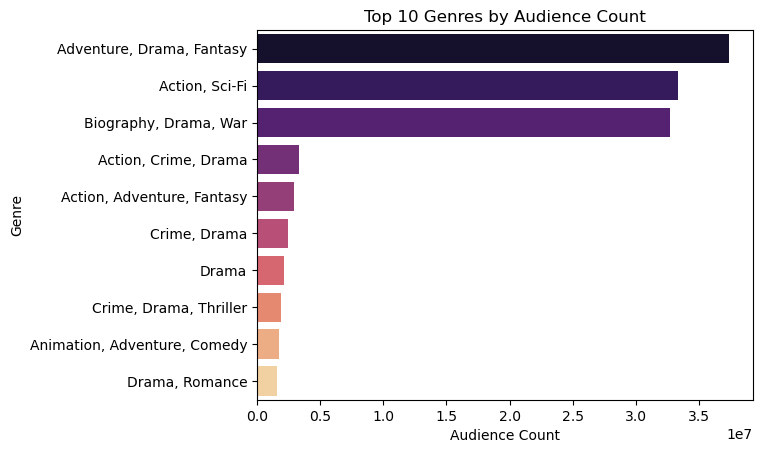

In [5]:
# Group the data by 'genre', sum the 'audience_count' for each genre,
# get the top 10 genres with the highest audience counts, and reset the index.
genre_audience = (
    joined_movies_dataset.groupby('genre')['Audience Count']
    .sum()
    .nlargest(10)
    .reset_index()
)

# Plotting the top 10 genres by audience count using seaborn's barplot.
sns.barplot(data=genre_audience, x='Audience Count', y='genre', hue='genre', palette='magma', legend=False)

plt.title("Top 10 Genres by Audience Count")
plt.xlabel("Audience Count")
plt.ylabel("Genre")
plt.show()

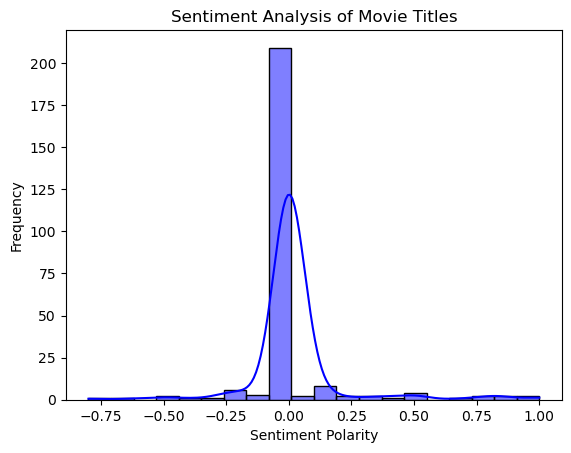

In [6]:
# Perform sentiment analysis to each movie title using TextBlob.
# 'TextBlob(x).sentiment.polarity' calculates the sentiment polarity of the title.
# The result is stored in a new column called 'title_sentiment'
joined_movies_dataset['title_sentiment'] = joined_movies_dataset['title'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Plot sentiment distribution.
# The 'histplot' function creates a histogram with a Kernel Density Estimate (KDE) overlay
sns.histplot(joined_movies_dataset['title_sentiment'], kde=True, bins=20, color='blue')
plt.title("Sentiment Analysis of Movie Titles")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

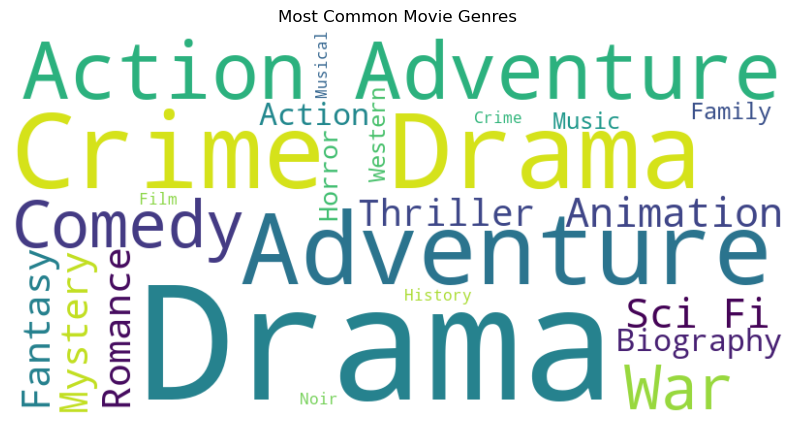

In [7]:
# Combine all the genres into a single string, removing any missing values (NaNs).
# The 'join' method merges all genre entries from the 'genre' column into one long string
all_genres = ' '.join(joined_movies_dataset['genre'].dropna())

# Generate a word cloud from the combined genre string.
# The WordCloud object takes the text (all_genres) and creates a visual representation.
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_genres)

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Movie Genres")
plt.show()

In [8]:
# Check if both 'boxoffice' and 'genre' columns exist in the dataset.
if 'boxoffice' in joined_movies_dataset.columns and 'genre' in joined_movies_dataset.columns:
    
    # Group the data by 'genre', sum the 'boxoffice' revenue for each genre,
    # sort the values in descending order, and get the top 10 genres.
    boxoffice_by_genre = (joined_movies_dataset.groupby('genre')['boxoffice']
                          .sum()
                          .sort_values(ascending=False)
                          .head(10))
    
    plt.figure(figsize=(12, 6))
    boxoffice_by_genre.plot(kind='bar', color='green')
    plt.title('Top 10 Genres by Total Box Office Revenue', fontsize=16)
    plt.xlabel('Genre', fontsize=14)
    plt.ylabel('Total Box Office Revenue', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

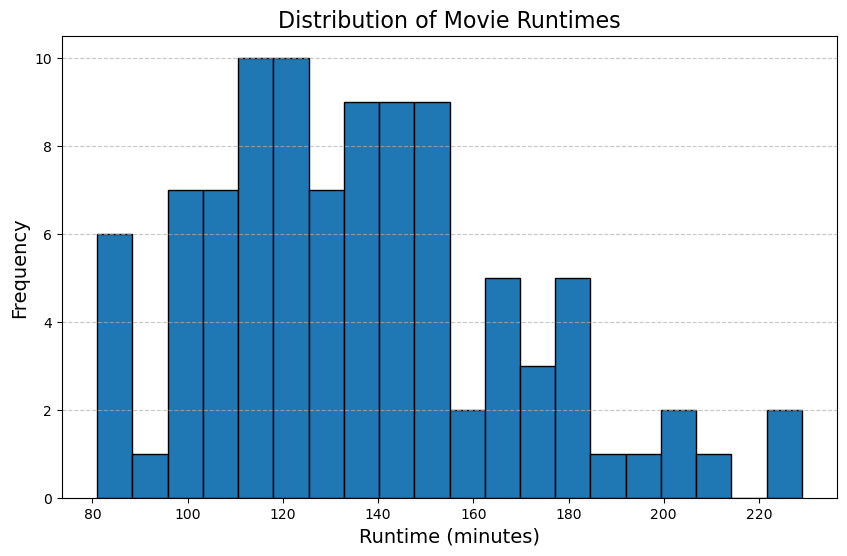

In [9]:
# Check if the 'runtime' column exists in the dataset.
if 'runtime' in joined_movies_dataset.columns:
    plt.figure(figsize=(10, 6))
    
    # Plot the histogram of movie runtimes, excluding missing values (dropna).
    plt.hist(joined_movies_dataset['runtime'].dropna(), bins=20, edgecolor='black')
    plt.title('Distribution of Movie Runtimes', fontsize=16)
    plt.xlabel('Runtime (minutes)', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Summary of Data Changes and Ethical Considerations 

In this project, I worked with several datasets to analyze movie-related information. Here's a summary of the changes I made to the data, ethical considerations, and how I addressed them. 

#### Changes Made to the Data 

1. **Handling Missing Values:** Missing information in columns like `runtime` and `ratings` was either filled using averages or other logical methods or left out when it was unclear how to replace it. 
2. **Outliers:** Extremely high or low values, like unrealistic movie runtimes, were removed to avoid skewing the analysis. 
3. **Standardizing Data:** Columns like `movie titles` were cleaned to ensure consistency in capitalization and formatting. This helped when merging datasets. 
4. **Feature Engineering:** New columns were created from existing data, such as extracting the release year from a date column. 
5. **Encoding Data:** Text-based columns like `genres` and `content_rating` were converted into numerical formats to prepare for model building. 
6. **Merging Data:** Data from multiple sources were combined using unique identifiers like `IMDb ID` to ensure the information was correctly aligned. 

#### Legal and Regulatory Guidelines 

The data came from sources like [Rotten Tomatoes Movies and Critic Reviews Dataset](https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset), [IMDb Top 250 Movies](https://www.imdb.com/chart/top/?ref_=nv_mv_250), and [The Open Movie Database](https://www.omdbapi.com/), all providing access under clear terms of use. I adhered to these policies, avoiding any unauthorized scraping or data extraction. No personal or sensitive information was included, ensuring compliance with data privacy laws like GDPR (General Data Protection Regulation). 

#### Risks from Data Transformations 

Some risks emerged from the data changes: 

- Imputed missing values might have introduced bias. 
- Combining datasets could lead to errors if records didn't align correctly. 
- Simplifying text data for numerical use could lose nuanced information. 

#### Assumptions in Data Cleaning 

- Missing values, like `runtime`, were assumed to follow existing data patterns. 
- Columns across datasets, such as `ratings` and `genres`, referred to the same definitions. 
- Data merging based on unique IDs was assumed to be accurate. 

#### Data Credibility and Sourcing 

The datasets were obtained from trusted platforms like APIs, ensuring high-quality information. Cross-checking some values verified their credibility. 

#### Ethical Considerations and Solutions 

The data was collected and processed ethically: 

- Assumptions and changes were documented. 
- Missing data handling was designed to minimize distortion. 
- Validation checks ensured the accuracy of merging and transformations. 
- Findings were interpreted with care, acknowledging limitations.

By being transparent and careful, I ensured the data transformations respected ethical standards and produced reliable, meaningful insights. 

In [10]:
df1.head(60)

,rank,title,release_year,content_rating,rating,runtime_minutes,rating_scaled
0,1,The Shawshank Redemption,1994,R,9.3,142,93.0
1,2,The Godfather,1972,R,9.2,175,92.0
2,3,The Dark Knight,2008,PG-13,9.0,152,90.0
3,4,The Godfather Part II,1974,R,9.0,202,90.0
4,5,12 Angry Men,1957,Approved,9.0,96,90.0
5,6,The Lord of the Rings: The Return of the King,2003,PG-13,9.0,201,90.0
6,7,Schindler's List,1993,R,9.0,195,90.0
7,8,Pulp Fiction,1994,R,8.9,154,89.0
8,9,The Lord of the Rings: The Fellowship of the Ring,2001,PG-13,8.9,178,89.0
9,10,"The Good, the Bad and the Ugly",1966,R,8.8,178,88.0


In [11]:
df2.head(60)

,title,year,rating,release_date,runtime,genre,director,writer,actors,plot,Country,Awards,Metascore,imdbRating,imdbVotes,imdbID,BoxOffice,rt_rating
0,The Shawshank Redemption,1994,R,1994-10-14,142.0,Drama,Frank Darabont,"Stephen King, Frank Darabont","Tim Robbins, Morgan Freeman, Bob Gunton",A wrongfully convicted banker forms a close fr...,United States,Nominated for 7 Oscars. 21 wins & 42 nominatio...,82.0,9.3,"3,182,645",tt0111161,"$28,767,189",89%
1,The Godfather,1972,R,1972-03-24,175.0,"Crime, Drama",Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Marlon Brando, Al Pacino, James Caan",The aging patriarch of an organized crime dyna...,United States,Won 3 Oscars. 31 wins & 31 nominations total,100.0,9.2,"2,222,804",tt0068646,"$136,381,073",97%
2,The Dark Knight,2008,PG-13,2008-07-18,152.0,"Action, Crime, Drama",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer","Christian Bale, Heath Ledger, Aaron Eckhart",When a menace known as the Joker wreaks havoc ...,"United States, United Kingdom",Won 2 Oscars. 163 wins & 165 nominations total,85.0,9.1,"3,161,907",tt0468569,"$534,987,076",94%
3,The Godfather Part II,1974,R,1974-12-18,202.0,"Crime, Drama",Francis Ford Coppola,"Francis Ford Coppola, Mario Puzo","Al Pacino, Robert De Niro, Robert Duvall",The early life and career of Vito Corleone in ...,United States,Won 6 Oscars. 17 wins & 21 nominations total,90.0,9.0,"1,492,120",tt0071562,"$47,834,595",96%
4,12 Angry Men,1957,Approved,1957-04-10,96.0,"Crime, Drama",Sidney Lumet,Reginald Rose,"Henry Fonda, Lee J. Cobb, Martin Balsam",The jury in a New York City murder trial is fr...,United States,Nominated for 3 Oscars. 16 wins & 12 nominatio...,97.0,9.0,"981,488",tt0050083,NaN,100%
5,The Lord of the Rings: The Return of the King,2003,PG-13,2003-12-17,201.0,"Adventure, Drama, Fantasy",Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens","Elijah Wood, Viggo Mortensen, Ian McKellen",Gandalf and Aragorn lead the World of Men agai...,"New Zealand, United States",Won 11 Oscars. 215 wins & 124 nominations total,94.0,9.0,"2,161,991",tt0167260,"$386,975,644",94%
6,Schindler's List,1994,R,1994-02-04,195.0,"Biography, Drama, History",Steven Spielberg,"Thomas Keneally, Steven Zaillian","Liam Neeson, Ralph Fiennes, Ben Kingsley","In German-occupied Poland during World War II,...",United States,Won 7 Oscars. 91 wins & 49 nominations total,95.0,9.0,"1,582,378",tt0108052,"$96,898,818",98%
7,Pulp Fiction,1994,R,1994-10-14,154.0,"Crime, Drama",Quentin Tarantino,"Quentin Tarantino, Roger Avary","John Travolta, Uma Thurman, Samuel L. Jackson","The lives of two mob hitmen, a boxer, a gangst...",United States,Won 1 Oscar. 69 wins & 72 nominations total,95.0,8.8,"2,431,656",tt0110912,"$107,928,762",92%
8,The Lord of the Rings: The Fellowship of the Ring,2001,PG-13,2001-12-19,178.0,"Adventure, Drama, Fantasy",Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens","Elijah Wood, Ian McKellen, Orlando Bloom",A meek Hobbit from the Shire and eight compani...,"New Zealand, United States",Won 4 Oscars. 126 wins & 127 nominations total,92.0,8.9,"2,203,785",tt0120737,"$325,873,309",91%
9,"The Good, the Bad and the Ugly",1967,R,1967-12-29,178.0,"Adventure, Drama, Western",Sergio Leone,"Luciano Vincenzoni, Sergio Leone, Agenore Incr...","Clint Eastwood, Eli Wallach, Lee Van Cleef",A bounty-hunting scam joins two men in an unea...,"Italy, Spain, West Germany, United States",2 wins & 5 nominations total,90.0,8.8,"889,734",tt0060196,"$25,100,000",97%


In [12]:
df3.head(60)

,Rotten Tomatoes Link,Movie Title,Movie Info,Critics Consensus,Content Rating,Genres,Directors,Authors,Actors,Original Release Date,...,Audience Status,Audience Rating,Audience Count,Tomatometer Top Critics Count,Tomatometer Fresh Critics Count,Tomatometer Rotten Critics Count,z_score_Tomatometer Rating,z_score_Audience Rating,z_score_Tomatometer Count,z_score_Audience Count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,Spilled,53.0,254421.0,43,73,76,-0.422902,-0.378467,1.382400,0.073007
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Upright,64.0,11574.0,44,123,19,0.914255,0.161389,1.278319,-0.072841
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Spilled,53.0,14684.0,2,16,8,0.210488,-0.378467,-0.476184,-0.070973
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Upright,97.0,105386.0,6,54,0,1.371703,1.780959,-0.030124,-0.016500
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Upright,74.0,68918.0,5,24,3,0.984632,0.652168,-0.431578,-0.038402
5,m/10000_bc,"10,000 B.C.",Mammoth hunter D'Leh (Steven Strait) has long ...,With attention strictly paid to style instead ...,PG-13,"Action & Adventure, Classics, Drama",Roland Emmerich,"Harald Kloser, Roland Emmerich","Steven Strait, Camilla Belle, Cliff Curtis, Jo...",2008-03-07,...,Spilled,37.0,411140.0,37,12,137,-1.865624,-1.163713,1.382400,0.167128
6,m/1000121-39_steps,The 39 Steps,"While on vacation in London, Canadian Richard ...","Packed with twists and turns, this essential e...",NR,"Action & Adventure, Classics, Mystery & Suspense",Alfred Hitchcock,"Alma Reville, Charles Bennett, Ian Hay, Alfred...","Robert Donat, Madeleine Carroll, Godfrey Tearl...",1935-08-01,...,Upright,86.0,23890.0,8,49,2,1.230950,1.241102,-0.074730,-0.065444
7,m/1000123-310_to_yuma,3:10 to Yuma,"Dan Evans (Van Heflin), a drought-plagued Ariz...",No Consensus,NR,"Classics, Drama, Western",Delmer Daves,Halsted Welles,"Glenn Ford, Van Heflin, Felicia Farr, Leora Da...",1957-08-07,...,Upright,79.0,9243.0,6,27,1,1.230950,0.897557,-0.416710,-0.074241
8,m/10002008-charly,Charly (A Heartbeat Away),"Cultural differences, past loves and personal ...",No Consensus,PG,"Comedy, Drama, Romance",Adam Thomas Anderegg,"Jack Weyland, Janine Whetton Gilbert","Heather Beers, Gary Neilson, Lisa McCammon, Ja...",2002-09-27,...,Upright,87.0,4819.0,0,2,8,-1.443364,1.290180,-0.684346,-0.076898
9,m/1000204-abraham_lincoln,Abraham Lincoln,The 16th U.S. president (Walter Huston) is por...,No Consensus,NR,"Classics, Drama",D.W. Griffith,"Gerrit J. Lloyd, Stephen Vincent Benét","Walter Huston, Una Merkel, Kay Hammond, Ian Ke...",1930-11-08,...,Spilled,40.0,457.0,4,9,2,0.738313,-1.016479,-0.669477,-0.079518


In [13]:
joined_df.head(60)

,rank,title,release_year,content_rating,rating,runtime_minutes,rating_scaled,title,year,rating,...,Audience Status,Audience Rating,Audience Count,Tomatometer Top Critics Count,Tomatometer Fresh Critics Count,Tomatometer Rotten Critics Count,z_score_Tomatometer Rating,z_score_Audience Rating,z_score_Tomatometer Count,z_score_Audience Count
0,1,The Shawshank Redemption,1994,R,9.3,142,93.0,The Shawshank Redemption,1994.0,R,...,Upright,98.0,886485.0,19.0,68.0,7.0,1.055008,1.830037,0.282118,0.452609
1,2,The Godfather,1972,R,9.2,175,92.0,The Godfather,1972.0,R,...,Upright,98.0,733939.0,24.0,97.0,2.0,1.301327,1.830037,0.638966,0.360994
2,3,The Dark Knight,2008,PG-13,9.0,152,90.0,The Dark Knight,2008.0,PG-13,...,Upright,94.0,1831566.0,63.0,320.0,20.0,1.160573,1.633725,4.222318,1.020201
3,4,The Godfather Part II,1974,R,9.0,202,90.0,The Godfather Part II,1974.0,R,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,12 Angry Men,1957,Approved,9.0,96,90.0,12 Angry Men,1957.0,Approved,...,Upright,87.0,20468.0,0.0,11.0,1.0,1.090197,1.290180,-0.654609,-0.067500
5,6,The Lord of the Rings: The Return of the King,2003,PG-13,9.0,201,90.0,The Lord of the Rings: The Return of the King,2003.0,PG-13,...,Upright,86.0,34679773.0,53.0,257.0,18.0,1.125385,1.241102,3.255854,20.748027
6,7,Schindler's List,1993,R,9.0,195,90.0,Schindler's List,1994.0,R,...,Upright,97.0,411608.0,24.0,97.0,3.0,1.266138,1.780959,0.653835,0.167410
7,8,Pulp Fiction,1994,R,8.9,154,89.0,Pulp Fiction,1994.0,R,...,Upright,96.0,1127813.0,32.0,97.0,9.0,1.090197,1.731881,0.743047,0.597545
8,9,The Lord of the Rings: The Fellowship of the Ring,2001,PG-13,8.9,178,89.0,The Lord of the Rings: The Fellowship of the Ring,2001.0,PG-13,...,Upright,95.0,1355751.0,48.0,213.0,20.0,1.055008,1.682803,2.631369,0.734439
9,10,"The Good, the Bad and the Ugly",1966,R,8.8,178,88.0,"The Good, the Bad and the Ugly",1967.0,R,...,Upright,97.0,239803.0,15.0,72.0,2.0,1.266138,1.780959,0.267249,0.064228


In [14]:
joined_movies_dataset.head(60)

,rank,title,release_year,content_rating,rating,runtime_minutes,rating_scaled,title.1,year,rating.1,...,Audience Rating,Audience Count,Tomatometer Top Critics Count,Tomatometer Fresh Critics Count,Tomatometer Rotten Critics Count,z_score_Tomatometer Rating,z_score_Audience Rating,z_score_Tomatometer Count,z_score_Audience Count,title_sentiment
0,1,The Shawshank Redemption,1994,R,9.3,142,93.0,The Shawshank Redemption,1994.0,R,...,98.0,886485.0,19.0,68.0,7.0,1.055008,1.830037,0.282118,0.452609,0.000000
1,2,The Godfather,1972,R,9.2,175,92.0,The Godfather,1972.0,R,...,98.0,733939.0,24.0,97.0,2.0,1.301327,1.830037,0.638966,0.360994,0.000000
2,3,The Dark Knight,2008,PG-13,9.0,152,90.0,The Dark Knight,2008.0,PG-13,...,94.0,1831566.0,63.0,320.0,20.0,1.160573,1.633725,4.222318,1.020201,-0.150000
3,4,The Godfather Part II,1974,R,9.0,202,90.0,The Godfather Part II,1974.0,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
4,5,12 Angry Men,1957,Approved,9.0,96,90.0,12 Angry Men,1957.0,Approved,...,87.0,20468.0,0.0,11.0,1.0,1.090197,1.290180,-0.654609,-0.067500,-0.500000
5,6,The Lord of the Rings: The Return of the King,2003,PG-13,9.0,201,90.0,The Lord of the Rings: The Return of the King,2003.0,PG-13,...,86.0,34679773.0,53.0,257.0,18.0,1.125385,1.241102,3.255854,20.748027,0.000000
6,7,Schindler's List,1993,R,9.0,195,90.0,Schindler's List,1994.0,R,...,97.0,411608.0,24.0,97.0,3.0,1.266138,1.780959,0.653835,0.167410,0.000000
7,8,Pulp Fiction,1994,R,8.9,154,89.0,Pulp Fiction,1994.0,R,...,96.0,1127813.0,32.0,97.0,9.0,1.090197,1.731881,0.743047,0.597545,0.000000
8,9,The Lord of the Rings: The Fellowship of the Ring,2001,PG-13,8.9,178,89.0,The Lord of the Rings: The Fellowship of the Ring,2001.0,PG-13,...,95.0,1355751.0,48.0,213.0,20.0,1.055008,1.682803,2.631369,0.734439,0.000000
9,10,"The Good, the Bad and the Ugly",1966,R,8.8,178,88.0,"The Good, the Bad and the Ugly",1967.0,R,...,97.0,239803.0,15.0,72.0,2.0,1.266138,1.780959,0.267249,0.064228,-0.233333
